In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
from collections import defaultdict

C:\Users\HubOne\OneDrive - Tyler Systems\Documents\GitHub\ConfidantNVDRS\local_server\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

# Load the Llama 3.1 Instruct tokenizer
tokenizer = AutoTokenizer.from_pretrained("//wsl.localhost/Ubuntu/home/tylersystems/models/NVDRS-v0.3")

# Assuming training_data is a list of 43 dictionaries with the structure shown in your example
# Each dictionary has a 'conversation' key with a list of messages (system, user, assistant)

# Initialize dictionaries to store token counts for each role
token_counts = {
    'system': [],
    'user': [],
    'assistant': []
}


### Loading the training dataset

In [5]:
training_data_path = './training/automated_runpod_training_pipeline/all_conversations.jsonl'

In [6]:
training_data = []

with open(training_data_path, 'r') as f:
    lines = f.readlines()
    for line in lines:
        data = json.loads(line)
        training_data.append(data)

### Content Analysis By Role

In [7]:
# Iterate through all conversations in the training data
for conversation_data in training_data:
    conversation = conversation_data['conversation']
    
    # Process each message in the conversation
    for message in conversation:
        role = message['role']
        content = message['content']
        
        # Only process if the role is one we're tracking
        if role in token_counts:
            # Tokenize the content
            tokens = tokenizer.encode(content)
            token_count = len(tokens)
            
            # Add the token count to the appropriate list
            token_counts[role].append(token_count)

In [8]:
# Calculate statistics for each role
stats = {}
for role, counts in token_counts.items():
    if counts:  # Check if the list is not empty
        stats[role] = {
            'mean': np.mean(counts),
            'median': np.median(counts),
            'min': np.min(counts),
            'max': np.max(counts),
            'p25': np.percentile(counts, 25),
            'p75': np.percentile(counts, 75),
            'p90': np.percentile(counts, 90),
            'count': len(counts)
        }

# Print the statistics
print("Token Count Statistics:")
for role, role_stats in stats.items():
    print(f"\n{role.upper()} Role:")
    for stat_name, stat_value in role_stats.items():
        # Format as integer for count metrics, float for others
        if stat_name == 'count':
            print(f"  {stat_name}: {int(stat_value)}")
        else:
            print(f"  {stat_name}: {stat_value:.2f}")

Token Count Statistics:

SYSTEM Role:
  mean: 1435.00
  median: 1435.00
  min: 1435.00
  max: 1435.00
  p25: 1435.00
  p75: 1435.00
  p90: 1435.00
  count: 43

USER Role:
  mean: 2201.65
  median: 2219.00
  min: 1989.00
  max: 2489.00
  p25: 2087.50
  p75: 2309.50
  p90: 2355.60
  count: 43

ASSISTANT Role:
  mean: 151.16
  median: 150.00
  min: 99.00
  max: 219.00
  p25: 139.00
  p75: 160.00
  p90: 174.40
  count: 43


In [9]:
# Create a DataFrame for easier visualization
data_for_plot = []
for role, counts in token_counts.items():
    for count in counts:
        data_for_plot.append({'Role': role, 'Token Count': count})

df = pd.DataFrame(data_for_plot)

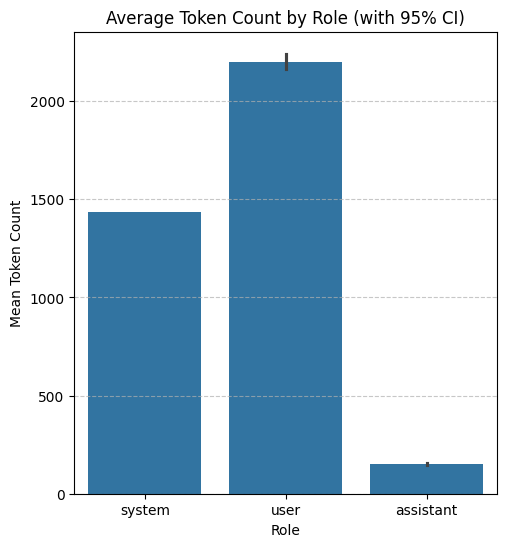

In [10]:
# Create a bar plot showing the mean token count for each role with error bars
plt.figure(figsize=(12, 6))

# Plot 1: Bar chart with means and error bars
plt.subplot(1, 2, 1)
sns.barplot(x='Role', y='Token Count', data=df, estimator=np.mean, errorbar=('ci', 95))
plt.title('Average Token Count by Role (with 95% CI)')
plt.ylabel('Mean Token Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

### Total Content Analysis

In [12]:
# Calculate total tokens per conversation
total_tokens_per_conversation = defaultdict(int)
for i, conversation_data in enumerate(training_data):
    conversation = conversation_data['conversation']
    for message in conversation:
        role = message['role']
        if role in token_counts:
            content = message['content']
            tokens = tokenizer.encode(content)
            total_tokens_per_conversation[i] += len(tokens)

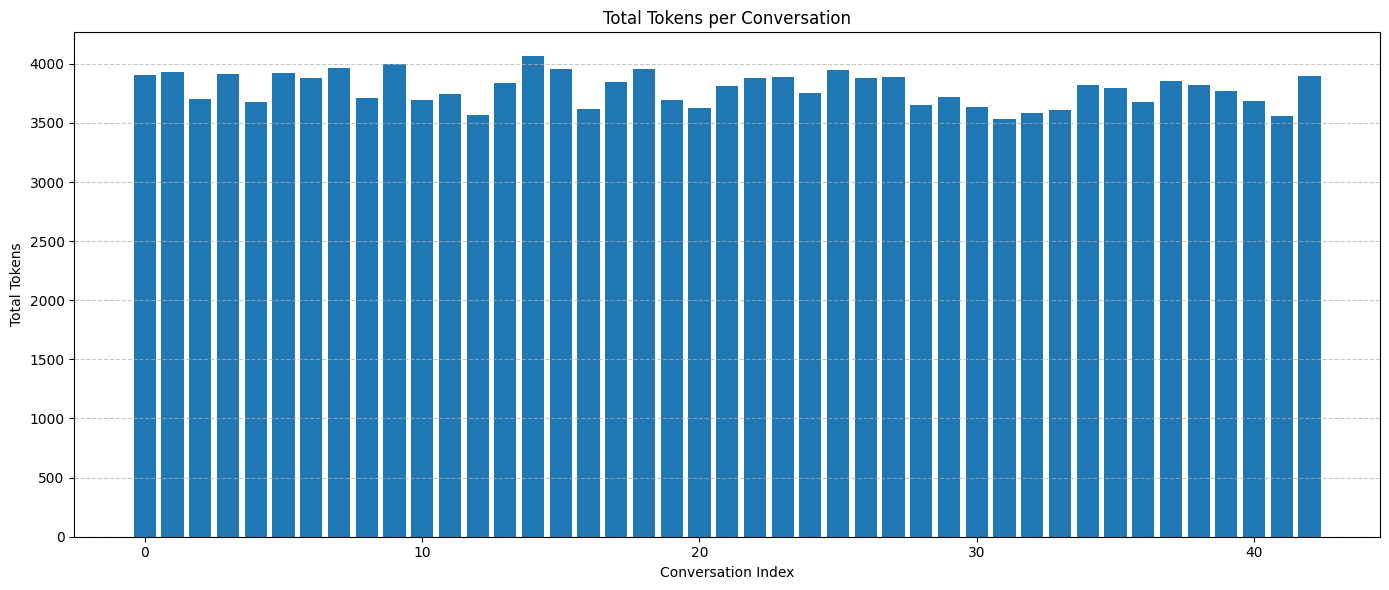

In [13]:
# Plot the total tokens per conversation
plt.figure(figsize=(14, 6))
plt.bar(total_tokens_per_conversation.keys(), total_tokens_per_conversation.values())
plt.xlabel('Conversation Index')
plt.ylabel('Total Tokens')
plt.title('Total Tokens per Conversation')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
# Calculate and print overall statistics
all_tokens = list(total_tokens_per_conversation.values())
print("Overall Conversation Token Statistics:")
print(f"Mean tokens per conversation: {np.mean(all_tokens):.2f}")
print(f"Median tokens per conversation: {np.median(all_tokens):.2f}")
print(f"Min tokens per conversation: {np.min(all_tokens)}")
print(f"Max tokens per conversation: {np.max(all_tokens)}")
print(f"25th percentile: {np.percentile(all_tokens, 25):.2f}")
print(f"75th percentile: {np.percentile(all_tokens, 75):.2f}")
print(f"90th percentile: {np.percentile(all_tokens, 90):.2f}")
print(f"Number of conversations: {len(all_tokens)}")

Overall Conversation Token Statistics:
Mean tokens per conversation: 3787.81
Median tokens per conversation: 3816.00
Min tokens per conversation: 3532
Max tokens per conversation: 4063
25th percentile: 3683.50
75th percentile: 3894.00
90th percentile: 3954.40
Number of conversations: 43
